In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import networkx as nx
from functions.SQUIC_functions import squic_fit_sparse, check_symmetric_sparse, read_lambdas
from networkx.algorithms import community
import igraph as ig
import leidenalg as la
from sklearn.cluster import DBSCAN
from functions.spectral_clustering import find_optimal_clusters, compute_spectral_clustering 
from functions.internal import load_dataset
from functions.plots import plot_timeseries, plot_PDens_Q_Times, plot_theta
import os
from functions.clustering_functions import labels_to_partition, compute_partition_density
from functions.cosmograph_functions import cosmograph_from_theta, visualize_graph_experiment1

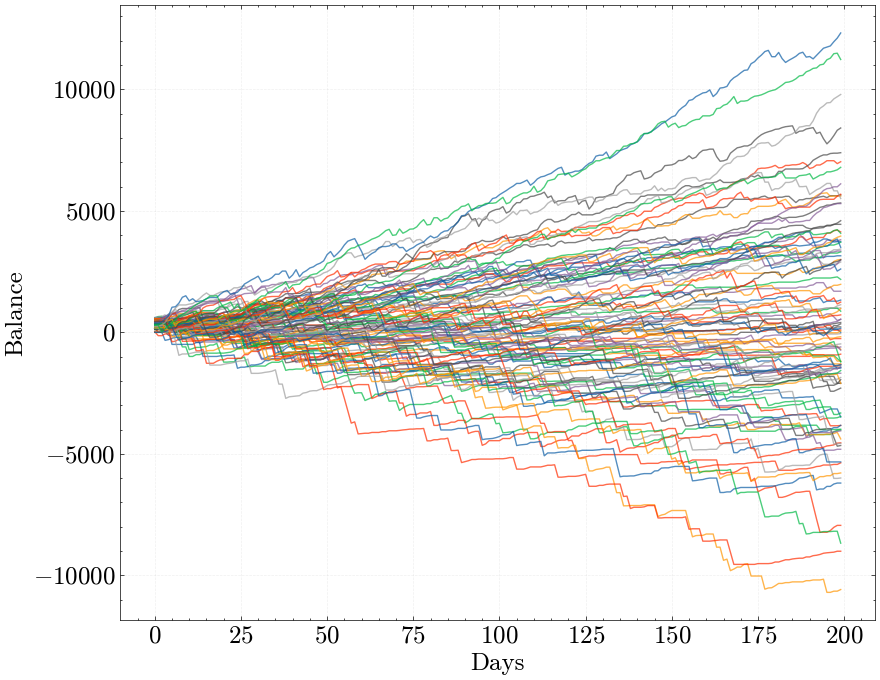

Data with 194 samples after decomposition.
-> Standardizing (normalizing) data...


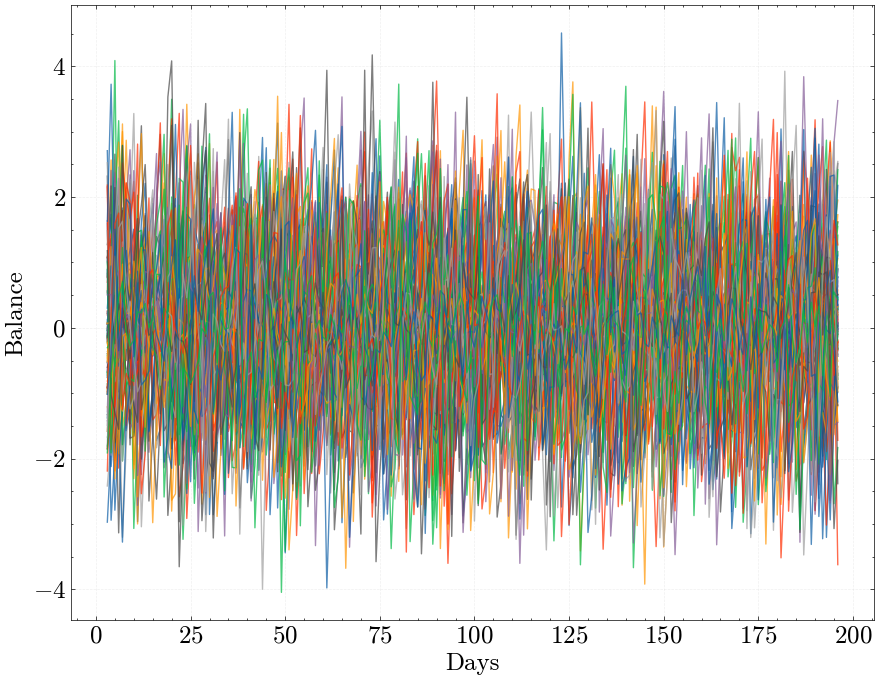

           0         1         2         3         4         5         6   \
3    1.026915 -0.676972  0.536717  0.011661 -0.193542  1.603111  1.033776   
4    0.224495 -0.270399  2.566603  0.173668  2.407355 -1.347344  0.627648   
5   -0.206856 -0.047983 -0.992983  0.050385 -0.123864 -0.471671  0.007167   
6   -0.429612  0.157224 -0.058274 -0.520554 -0.561126  0.603163 -0.117595   
7    0.345597  0.183327  0.502256 -0.876866 -1.007393  1.223695 -0.294736   
..        ...       ...       ...       ...       ...       ...       ...   
192  0.153671  1.600078  0.501391  0.447443  0.174574  1.211103  0.249135   
193  0.787862 -2.013546  1.585795  0.391559 -0.526203  1.144185  0.084560   
194  0.509418 -1.131582  2.861044  0.234854 -0.291085  1.485426 -0.264377   
195  0.781421 -0.525853  1.677159  0.032853  2.829483 -1.156820 -0.117595   
196  0.775812  0.081278 -0.919825 -0.102244  3.474421 -0.982987 -0.356577   

           7         8         9   ...        90        91        92  \
3  

In [2]:
Y, name, dim, _ = load_dataset()

PLOT = True
SAVE_FIG = False
if SAVE_FIG:
    SAVE_FIG_DIR = f'decomposition/glasso_images/{name.lower()}'

if PLOT:
    plot_timeseries(Y, name, dimension=dim)

all_residuals = { 
            account: seasonal_decompose(Y[account], model='additive', period=7).resid
            for account in Y.columns
        }
df_residuals = pd.DataFrame(all_residuals).dropna()
print(f"Data with {df_residuals.shape[0]} samples after decomposition.")

print("-> Standardizing (normalizing) data...")
residuals_matrix = df_residuals.values
col_std = np.std(residuals_matrix, axis=0, keepdims=True)
col_std[col_std == 0] = 1.0
prepared_data = residuals_matrix / col_std

df_prepared = pd.DataFrame(prepared_data, 
                        index=df_residuals.index, 
                        columns=df_residuals.columns)
if PLOT:
    plot_timeseries(df_prepared, "AMLSIM", dimension=dim)

print(df_prepared)

prepared_data = prepared_data.T
ROWS = prepared_data.shape[0]

lambdas = read_lambdas(name, dim, "no-bias")

-> Running SQUIC-Fit with lambda = 0.4...
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 194 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      4.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.81e-04 nnz(S)/p=2.10e+00
* iter=1 time=9.62e-04 obj=1.36e+02 |delta(obj)|/obj=2.62e-01 nnz(X,L,W)/p=[2.10e+00 2.53e+00 1.58e+00] lns_iter=1 
* iter=2 time=1.09e-03 obj=1.34e+02 |delta(obj)|/obj=1.41e-02 nnz(X,L,W)/p=[2.10e+00 2.53e+00 2.90e+00] lns_iter=1 
* iter=3 

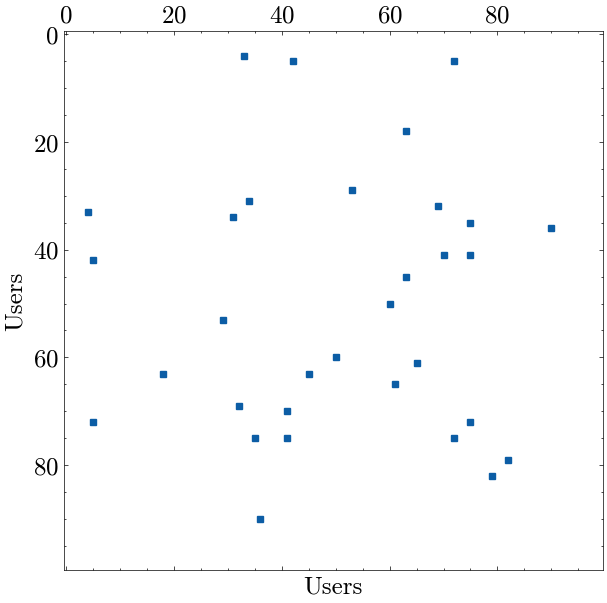

Is G connected for l=0.4? False
# CC : 84
louvain
spectral
dbscan
leiden
-> Running SQUIC-Fit with lambda = 0.2...
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 194 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.54e-04 nnz(S)/p=2.11e+01
* iter=1 time=1.63e-03 obj=1.15e+02 |delta(obj)|/obj=1.33e-01 nnz(X,L,W)/p=[2.11e+01 3.62e+01 1.22e+00] lns_iter=3 
* iter=2 time=2.62e-03 obj=1.15e+02 |delta(obj)|/obj

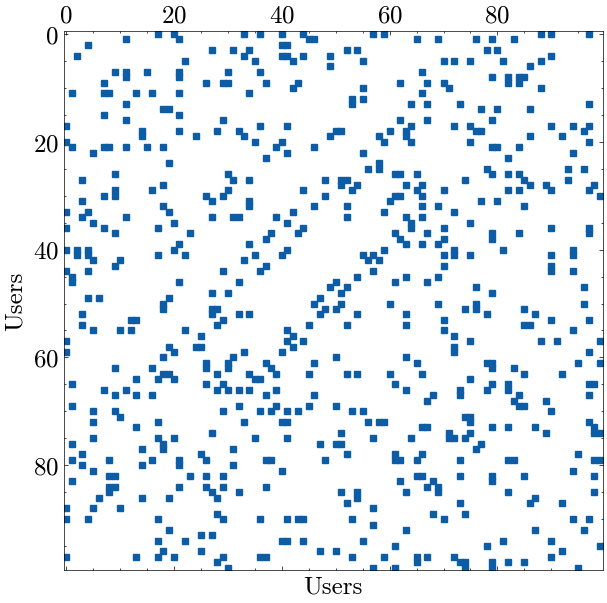

Is G connected for l=0.2? True
louvain
spectral
dbscan
leiden
-> Running SQUIC-Fit with lambda = 0.1...
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 194 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.43e-04 nnz(S)/p=5.47e+01
* iter=1 time=2.42e-03 obj=1.01e+02 |delta(obj)|/obj=1.21e-02 nnz(X,L,W)/p=[5.47e+01 4.69e+01 1.10e+00] lns_iter=4 
* iter=2 time=3.49e-03 obj=9.96e+01 |delta(obj)|/obj=1.60e-02 n

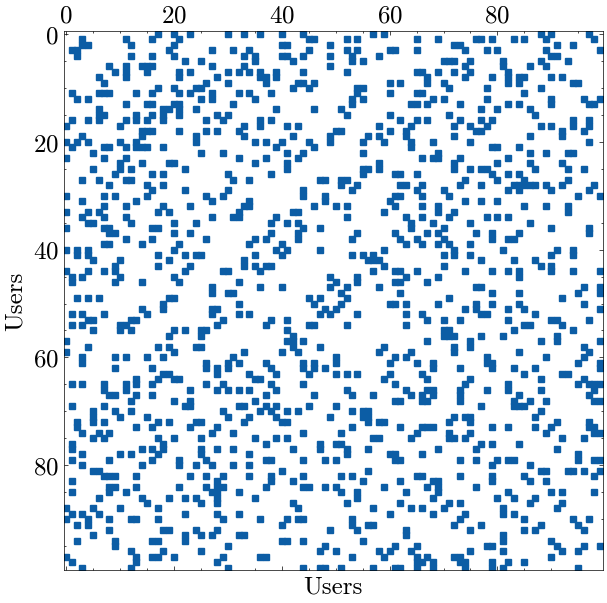

Is G connected for l=0.1? True
louvain
spectral
dbscan
leiden
-> Running SQUIC-Fit with lambda = 0.07...
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 194 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      7.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.27e-04 nnz(S)/p=6.76e+01
* iter=1 time=2.28e-03 obj=9.47e+01 |delta(obj)|/obj=5.55e-02 nnz(X,L,W)/p=[6.76e+01 4.91e+01 7.88e+00] lns_iter=4 
* iter=2 time=4.82e-03 obj=9.33e+01 |delta(obj)|/obj=1.57e-02 

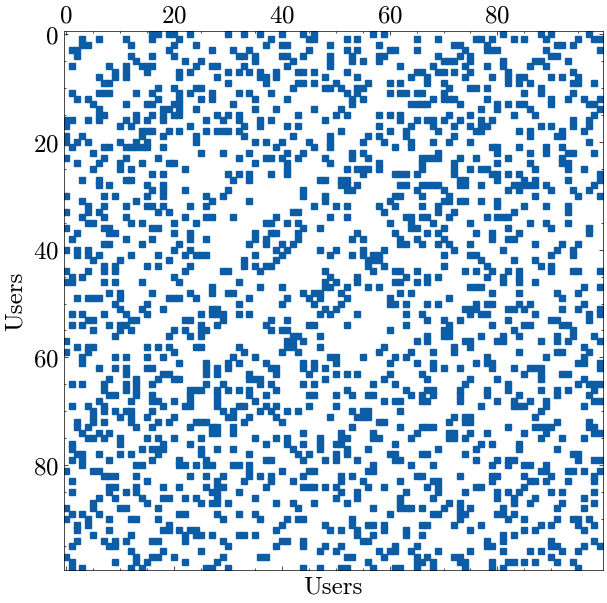

Is G connected for l=0.07? True
louvain
spectral
dbscan
leiden
-> Running SQUIC-Fit with lambda = 0.05...
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 194 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=7.34e-04 nnz(S)/p=7.74e+01
* iter=1 time=2.17e-03 obj=9.08e+01 |delta(obj)|/obj=1.01e-01 nnz(X,L,W)/p=[7.74e+01 5.00e+01 6.02e+01] lns_iter=4 
* iter=2 time=1.09e-02 obj=8.89e+01 |delta(obj)|/obj=2.11e-02

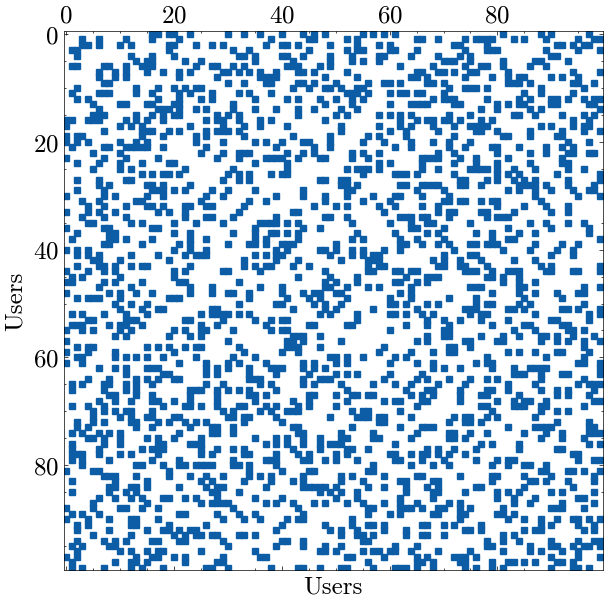

Is G connected for l=0.05? True
louvain
spectral
dbscan
leiden


In [3]:
int_metrics = {
    rho: {
        'louvain': {},
        'leiden': {},
        'dbscan': {},
        'spectral': {}
    } for rho in lambdas
}

results_squic = {
    name : {}
}

dict_cluster = {}

for LAMBDA in lambdas:
    # Run SQUIC-Fit
    print(f"-> Running SQUIC-Fit with lambda = {LAMBDA}...")
    theta, end_time = squic_fit_sparse(prepared_data, LAMBDA, LAMBDA/10)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    results_squic[name][LAMBDA] = theta

    int_metrics[LAMBDA]['time'] = end_time

    nnz = theta.count_nonzero()
    print(f"nnz = {int(nnz)} per rows = {round(int(nnz)/ROWS, 2)}")

    if check_symmetric_sparse(theta):
        print(f" Matrix is symmetric per lambda={LAMBDA}")
    else:
        print(f" Matrix is not symmetric per lambda={LAMBDA}")

    if PLOT:
        plot_theta(theta, name, dim, LAMBDA, SAVE_FIG)

    dict_cluster[LAMBDA] = {
        "louvain" : {},
        "spectral" : {},
        "dbscan" : {},
        "leiden" : {}
    }

    dbscan_params_dict = {
        '100' : {'epsilon' : 0.7,
                'min_samples' : 8},
        '1K' : {'epsilon' : 0.7,
                'min_samples' : 3},
        '10K' : {'epsilon' : 0.7,
                'min_samples' : 3},
        '100K' : {'epsilon' : 0.7,
                'min_samples' : 3},
        '1M' : {'epsilon' : 0.7,
                'min_samples' : 3}
    }

    # Ensure all off-diagonal entries are positive
    X = np.abs(theta) 
    # Ensure diagonal entries are zero
    X.setdiag(0) # SQUIC_Fit ensure that

    # Create a graph from matrix X
    G = nx.from_scipy_sparse_array(X)

    connected = nx.is_connected(G)
    print(f"Is G connected for l={LAMBDA}? {connected}")
    if not connected:
        connected_components = nx.connected_components(G)
        component_sizes = [len(c) for c in connected_components]
        print(f"# CC : {len(component_sizes)}")

    # Louvain
    partition_louvain = community.louvain_communities(G)
    dict_cluster[LAMBDA]['louvain'] = partition_louvain

    # Leiden
    G_igraph = ig.Graph.from_networkx(G)
    partition_leiden = la.find_partition(G_igraph, la.ModularityVertexPartition)
    dict_cluster[LAMBDA]['leiden'] = partition_leiden

    dbscan = DBSCAN(eps=dbscan_params_dict[dim]['epsilon'],
                        min_samples=dbscan_params_dict[dim]['min_samples'],
                        metric='cosine')
    labels_dbscan = dbscan.fit_predict(X)

    # Convert labels to list of sets
    partition_dbscan = labels_to_partition(labels_dbscan)
    dict_cluster[LAMBDA]['dbscan'] = partition_dbscan

    # Spectral Clustering
    optimal_k, eigenvectors = find_optimal_clusters(G, dim, plot=False)
    if eigenvectors is not None:
        labels_spectral = compute_spectral_clustering(eigenvectors, optimal_k, method='kmeans', plot=False)
        # Convert labels to list of sets
        partition_spectral = labels_to_partition(labels_spectral)

        dict_cluster[LAMBDA]['spectral'] = partition_spectral
    else:
        dict_cluster[LAMBDA]['spectral'] = None


    for method, partition in dict_cluster[LAMBDA].items():
        print(method)

        # Skip if partition is None
        if partition is None:
            print(f"[Warning] No partition for method={method}, lambda={LAMBDA}. Skipping.")

            int_metrics[LAMBDA][method]["p_density"] = 0
            int_metrics[LAMBDA][method]['modularity'] = 0
            int_metrics[LAMBDA][method]['CC'] = 0
            int_metrics[LAMBDA][method]['nCluster'] = 0
            int_metrics[LAMBDA][method]['isolated'] = "all isolated elements"
        else:
            m_total = G.number_of_edges()
            D_sum = 0
            isolated_node = 0
            density_sum = 0

            for comm in partition:
                n = len(comm)
                if n == 1:
                    isolated_node += 1
                    continue
                else:
                    if n >= 3: # skip communities too small for partition density
                        D_sum = compute_partition_density(G, comm, D_sum)
            
            partition_density = (2 / m_total) * D_sum if m_total > 0 else 0
            int_metrics[LAMBDA][method]["p_density"] = float(round(partition_density, 2))

            modularity = community.modularity(G, partition)
            int_metrics[LAMBDA][method]['modularity'] = float(round(modularity, 2))
            int_metrics[LAMBDA][method]["isolated"] = isolated_node
            int_metrics[LAMBDA][method]['CC'] = nx.number_connected_components(G)
            int_metrics[LAMBDA][method]['nCluster'] = len(partition)

In [4]:
widget_dict = {}
for rho, model_fit in results_squic[name].items():
    widget_dict = cosmograph_from_theta(model_fit, rho, widget_dict)


dimension_lambda = {
    "AMLSIM" : {
        "100" : 0.1,
        "1K" : 0.7,
        "10K" : 0.995,
        "100K" : 0.9995
    },
    "PAYSIM" : {
        "100" : 0.2,
        "1K" : 0.5,
        "10K" : 0.75,
        "100K" : 0.9
    }
}

widget_dict[dimension_lambda[name][dim]]

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…


Lambda = 0.4
    louvain : #Cluster = 84, p_density = 0.18, Q = 0.8
    leiden : #Cluster = 84, p_density = 0.18, Q = 0.8
    dbscan : #Cluster = 100, p_density = 0.0, Q = -0.05
    spectral : #Cluster = 5, p_density = 0.18, Q = 0.69

Lambda = 0.2
    louvain : #Cluster = 4, p_density = 0.18, Q = 0.48
    leiden : #Cluster = 7, p_density = 0.26, Q = 0.49
    dbscan : #Cluster = 19, p_density = 0.05, Q = 0.01
    spectral : #Cluster = 2, p_density = 0.12, Q = 0.38

Lambda = 0.1
    louvain : #Cluster = 6, p_density = 0.21, Q = 0.33
    leiden : #Cluster = 6, p_density = 0.25, Q = 0.31
    dbscan : #Cluster = 15, p_density = 0.11, Q = -0.0
    spectral : #Cluster = 2, p_density = 0.18, Q = 0.3

Lambda = 0.07
    louvain : #Cluster = 5, p_density = 0.2, Q = 0.26
    leiden : #Cluster = 7, p_density = 0.26, Q = 0.23
    dbscan : #Cluster = 6, p_density = 0.17, Q = -0.0
    spectral : #Cluster = 2, p_density = 0.21, Q = 0.25

Lambda = 0.05
    louvain : #Cluster = 5, p_density = 0.19, Q = 

/Users/claudio/Documents/USI/Tesi/FinancialCrimeModels/functions/plots.py:450: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


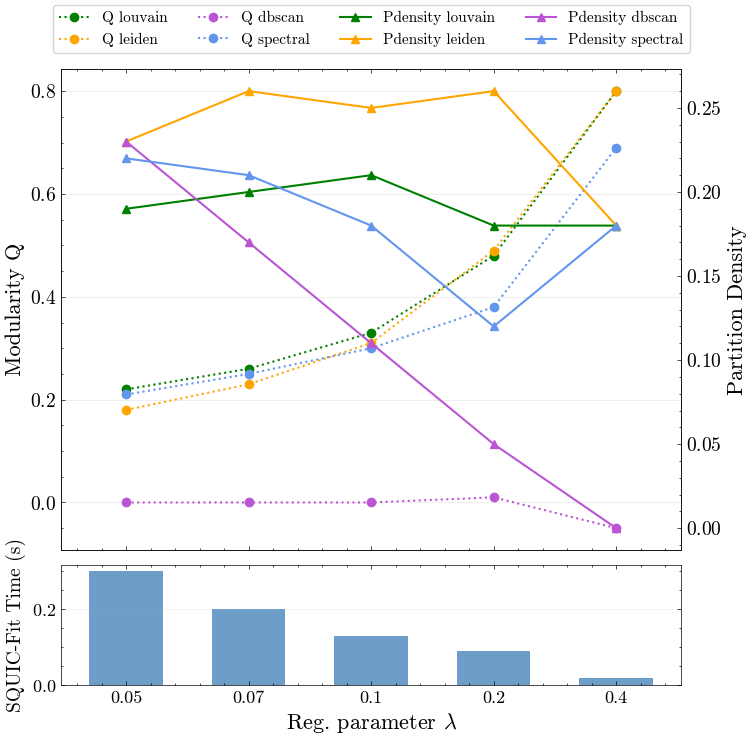

In [5]:
for rho, results in int_metrics.items():
    print()
    print(f"Lambda = {rho}")
    for method, metrics in results.items():
        if method == 'time':
            pass
        else:
            print(f"    {method} : #Cluster = {metrics['nCluster']}, p_density = {metrics['p_density']}, Q = {metrics['modularity']}")


if PLOT:
    plot_PDens_Q_Times(int_metrics, dim, name, save=SAVE_FIG)

In [9]:
graph = visualize_graph_experiment1(results_squic, name, dict_cluster)

cluster_method = 'louvain' # Change with the desidered cluster method: louvain, leiden, dbscan or spectral
graph[dimension_lambda[name][dim]].get(cluster_method.lower())

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…